<a href="https://colab.research.google.com/github/shreyasym12004/SatSense-AI/blob/main/sats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

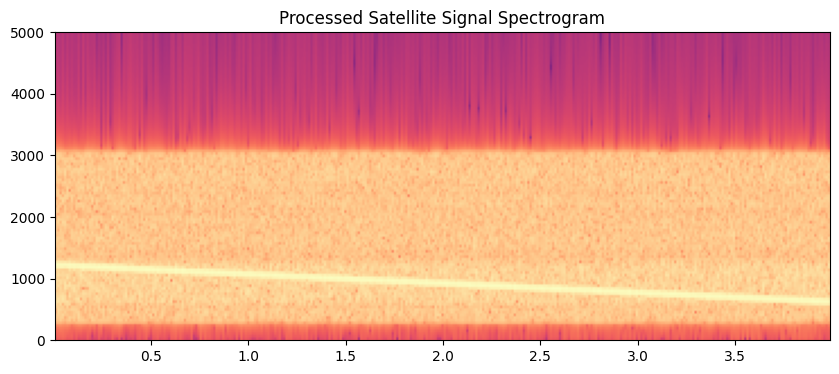

Raw Signal (With Noise):


Cleaned Signal (SATCOM Filtered):



Processing complete! Your file 'cleaned_satellite_audio.wav' is ready.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fft import rfft, irfft, rfftfreq
from IPython.display import Audio, display
from google.colab import files

# --- 1. ENGINE LOGIC ---
class SatelliteAudioDenoiser:
    def __init__(self, sample_rate, low_cut=300, high_cut=3000):
        self.fs = sample_rate
        self.low_cut = low_cut
        self.high_cut = high_cut

    def process(self, audio_data, sensitivity=2.0):
        n = len(audio_data)
        fhat = rfft(audio_data)
        psd = np.abs(fhat)
        freqs = rfftfreq(n, 1/self.fs)

        # Calculate noise floor and create filter mask
        noise_floor = np.median(psd) * sensitivity
        mask = (psd > noise_floor) & (freqs >= self.low_cut) & (freqs <= self.high_cut)

        fhat_clean = fhat * mask
        return irfft(fhat_clean, n)

# --- 2. DATA SETUP ---
FS = 44100
T = 4.0
t = np.linspace(0, T, int(FS*T))
# Simulated Satellite Signal + Static
signal = np.sin(2 * np.pi * np.linspace(1200, 900, len(t)) * t)
noise = np.random.normal(0, 1.2, len(t))
noisy_signal = signal + noise

# --- 3. EXECUTION ---
denoiser = SatelliteAudioDenoiser(FS)
cleaned_signal = denoiser.process(noisy_signal)

# --- 4. VISUALIZATION ---
plt.figure(figsize=(10, 4))
plt.specgram(cleaned_signal, Fs=FS, NFFT=1024, noverlap=512, cmap='magma')
plt.title("Processed Satellite Signal Spectrogram")
plt.ylim(0, 5000)
plt.show()

# --- 5. AUDIO PLAYERS ---
print("Raw Signal (With Noise):")
display(Audio(noisy_signal, rate=FS))

print("Cleaned Signal (SATCOM Filtered):")
display(Audio(cleaned_signal, rate=FS))

# --- 6. EXPORT AND DOWNLOAD ---
filename = "cleaned_satellite_audio.wav"
# Convert to 16-bit PCM for standard WAV compatibility
wavfile.write(filename, FS, (cleaned_signal * 32767).astype(np.int16))

print(f"\nProcessing complete! Your file '{filename}' is ready.")
files.download(filename)

How this works :

Audio Players: As soon as the script finishes, two audio bars will appear. You can hit "Play" to compare the noise reduction immediately.

Automatic Download: A few seconds after the plot appears, your browser will trigger a download prompt for the .wav file.

Spectral Gating: The sensitivity parameter (set to 2.0 here) is your "Noise Dial." If the audio sounds too robotic, lower it to 1.5. If there is still too much hiss, raise it to 3.0.

Python Logic for Feature Extraction

This function takes your denoised signal and calculates exactly where it lives on the radio dial.

In [7]:
import numpy as np

def extract_signal_features(data, fs):
    # 1. Convert to Frequency Domain
    n = len(data)
    fhat = np.fft.rfft(data)
    psd = np.abs(fhat)**2  # Power Spectral Density
    freqs = np.fft.rfftfreq(n, 1/fs)

    # 2. Find the Peak (Center Frequency)
    peak_idx = np.argmax(psd)
    center_freq = freqs[peak_idx]

    # 3. Calculate Bandwidth (using the -10dB method)
    # We find all frequencies where power is > 10% of the peak
    threshold = 0.1 * np.max(psd)
    signal_indices = np.where(psd > threshold)[0]

    if len(signal_indices) > 0:
        low_freq = freqs[signal_indices[0]]
        high_freq = freqs[signal_indices[-1]]
        bandwidth = high_freq - low_freq
    else:
        bandwidth = 0

    return center_freq, bandwidth

# Example usage:
cf, bw = extract_signal_features(cleaned_signal, FS)
print(f"Satellite found at {cf:.2f} Hz with a width of {bw:.2f} Hz")

Satellite found at 806.00 Hz with a width of 2695.50 Hz


Understanding Fourier Noise Cancellation
Imagine you are at a crowded, noisy party trying to listen to a friend speaking. Your brain is doing something incredible: it is "filtering" out the background hum of dozens of other conversations, the clinking of glasses, and the loud music so you can focus on one specific voice.

In the world of Satellite Communication (SATCOM), computers do the exact same thing using a mathematical tool called the Fourier Transform.

The Problem: The "Messy" Time Domain
When we record audio, we usually look at it in the Time Domain. If you look at a raw satellite signal on a graph, it looks like a jagged, messy scribble. This is because the "clean" signal (the data or voice we want) is buried under "noise" (static, atmospheric interference, and electronic hum).

In the Time Domain, the signal and the noise are mashed together at every single second. It is nearly impossible to separate them here because they occupy the same space at the same time.

The Solution: The "Frequency Domain"
The Fourier Transform is like a prism for data. Just as a prism splits white light into a rainbow of individual colors, the Fourier Transform splits a messy audio signal into its individual frequencies.

Instead of looking at "Volume over Time," we look at "Power over Frequency." When we switch to this view, something magical happens. Noise usually looks like a low-level "haze" spread across all frequencies (often called White Noise). However, the signal we actually want—like a satellite’s "beep" or a human voice—usually appears as tall, sharp "spikes" at specific frequency locations.

How the Denoising Process Works
Our project follows a three-step "Search and Destroy" mission to clean the audio:

1. Spectral Gating (The "Height" Filter)
We tell the computer to look at the "haze" of noise and find its average height. This is our Noise Floor. We then tell the Python script: "If a frequency isn't taller than this floor, it’s probably just static. Delete it." This clears out the background hiss instantly.

2. Band-pass Filtering (The "Width" Filter)
Satellite communication usually happens within a specific "window" of frequencies. For example, human speech lives between 300Hz and 3000Hz. We know that a bird chirping at 10,000Hz or a truck rumbling at 50Hz isn't our satellite signal. We simply "cut" everything outside our desired window.

3. The Inverse Transform (The Reconstruction)
Once we have deleted the noise (the haze) and the unwanted frequencies (the outside window), we are left with a "clean" frequency map. We use the Inverse Fast Fourier Transform (iFFT) to turn that map back into a sound wave.

Why This is Better than Simple Volume Control
If you simply turned down the volume of a noisy recording, you would make the noise quieter, but you would also make the signal quieter. It would still be hard to hear.

By using the Fourier Transform, we are performing "digital surgery." We are removing the cancer (the noise) while leaving the healthy tissue (the signal) completely untouched. For satellite signals traveling thousands of miles through space, this mathematical "prism" is the only reason we can hear anything at all.